In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from geopy.distance import great_circle
from shapely.geometry import MultiPoint
from sklearn.cluster import OPTICS  
from sklearn.preprocessing import StandardScaler
from hdbscan import HDBSCAN
import geopy.distance
import os


### Setup

Reading in data files

In [3]:
folder = "Stb_1HzData_og/"
def get_raw_data(folder):
    raw_trips = {}
    vehicle_efficiencies = []
    for root, dirs, files in os.walk(folder, topdown = True):
        for file in files:    
            if file.lower().endswith('.csv') and 'Battery' not in file:
                print("Reading:", file)
                route = root.split(os.sep)[1]
                time_of_day = root.split(os.sep)[2]
                if route not in raw_trips:
                    raw_trips[route] = {}
                if time_of_day not in raw_trips[route]:
                    raw_trips[route][time_of_day] = {}
                unit = os.path.splitext(file)[0]
                raw_trips[route][time_of_day][unit] = {}
                this_trip = pd.read_csv(root + "/" + file)
              #  this_trip = read_file(file,root, SUMO)
                if "GPS Speed" in this_trip.columns:
                    this_trip['Speed'] = this_trip['GPS Speed']
                raw_trips[route][time_of_day][unit] = this_trip
    return raw_trips
raw_trips = get_raw_data(folder)

Reading: UnitMain_9.CSV
Reading: Unit1_2.csv
Reading: UnitMain_10.CSV
Reading: Unit3_5.csv
Reading: Unit1_6.csv
Reading: Unit4_4.csv
Reading: UnitMain_3.csv
Reading: UnitMain_11.CSV
Reading: UnitMain_7.csv
Reading: Unit3_8.csv
Reading: Unit3_3.csv
Reading: Unit4_2.csv
Reading: UnitOG_5.CSV
Reading: UnitMain_1.csv
Reading: Unit1_10.csv
Reading: Unit4_7.csv
Reading: Unit2_9.csv
Reading: UnitMain_6.csv
Reading: Unit3_8.csv
Reading: Unit3_13.csv
Reading: Unit1_15.csv
Reading: UnitMain_11.csv
Reading: Unit4_12.csv
Reading: UnitOG_4.CSV
Reading: Unit3_6.csv
Reading: UnitMain_5.csv
Reading: Unit1_9.csv
Reading: Unit3_12.csv
Reading: Unit1_14.csv
Reading: UnitMain_10.csv
Reading: Unit4_3.csv
Reading: UnitMain_2.csv
Reading: Unit1_7.csv
Reading: Unit3_6.csv
Reading: Unit4_5.csv
Reading: UnitMain_4.csv
Reading: Unit1_10.csv
Reading: Unit4_8.csv
Reading: Unit2_9.csv
Reading: Unit4_2.csv
Reading: UnitOG_3.csv
Reading: UnitMain_1.csv
Reading: Unit1_7.csv
Reading: Unit3_6.csv
Reading: Unit4_5.csv
Re

Create set of possible break points where the EVs could charge

In [4]:
all_lats = []
all_lons = []
dwell_points = [] # list to hold all dwell points
min_dwell_time = 10 # minimum amount of time (s) a minibus must spend stopped for that place to be considered a dwell point
######### This value is just for testing. With ideal dataset of data lasting days or more, this would ideally be 20 minutes or more #############

for route, v in raw_trips.items():
    for time_of_day, v in raw_trips[route].items():
        for unit,journey in raw_trips[route][time_of_day].items():
            all_lats.extend(journey['Latitude'].tolist())
            all_lons.extend(journey['Longitude'].tolist())
            journey['dwell_identifier'] = journey.Speed.rolling(min_dwell_time).mean()
            this_journey_dwell_points = journey.loc[journey['dwell_identifier'] == 0, ['Latitude', 'Longitude']].values.tolist()
            for coords in this_journey_dwell_points:
                if coords not in dwell_points: # avoid repeats
                    dwell_points.append(coords)
all_coords = pd.DataFrame(np.unique(list(zip(all_lats, all_lons)), axis = 0), columns = ['lat', 'lon']) # only take unique coords for faster plotting later on
dwell_points_df = pd.DataFrame(dwell_points, columns = ['lat', 'lon'])
dwell_points = dwell_points_df.to_numpy() # don't need these to be unique 
print('There are', len(dwell_points), 'dwell points') # number of candidate dwell points identified


There are 221 dwell points


Running DBSCAN / OPTICS

In [5]:
#Parameters
kms_per_radian = 6371.0088
epsilon = 1 / kms_per_radian

#DBSCAN
db = DBSCAN(eps = epsilon, min_samples = 5, algorithm = 'ball_tree',
metric = 'haversine').fit(np.radians(dwell_points))

cluster_labels = db.labels_
num_clusters = len(set(cluster_labels))
clusters = pd.Series([dwell_points[cluster_labels == n] for n in range(num_clusters)])

#OPTICS
op = OPTICS(min_samples=10, max_eps=epsilon ,
                            metric='euclidean', cluster_method='dbscan',
                              n_jobs=1).fit(dwell_points)
op_labels = op.labels_
num_op_clusters = len(set(op_labels))
op_clusters = pd.Series([dwell_points[op_labels == n] for n in range(num_op_clusters)])

print('Number of DBSCAN clusters: {}'.format(num_clusters))
print('Number of OPTICS clusters: {}'.format(num_op_clusters))


Number of DBSCAN clusters: 7
Number of OPTICS clusters: 3


Forming new clusters based on certain radius (cluster optimization)


In [6]:
r = 3  #(km) Charging station cover radius. TODO: Use travel time instead of 'crow-flies' distance
cluster_means = [tuple(sum(c)/len(c)) for c in clusters if len(c) != 0]
new_clusters = []
for ref_point in cluster_means.copy():
    if ref_point in cluster_means:
      new_cluster = [] 
      new_cluster.append(ref_point) 
      cluster_means.remove(ref_point) 
      for other_point in cluster_means:
          if geopy.distance.geodesic(ref_point,other_point).km <= r:
              new_cluster.append(other_point)
              cluster_means.remove(other_point)
      new_clusters.append(pd.Series(new_cluster))



### Functions

In [7]:
'''Gets mean coordinates of a cluster
Works when inputted a list''' 
def get_cluster_mean(cluster):

    mean_coords = [sum(x)/len(x) for x in zip(*cluster)]
    return mean_coords

centermost_points = clusters.map(get_cluster_mean)
centermost_points_op = op_clusters.map(get_cluster_mean)

In [8]:
''' Similar to above function
Get mean coordinates of a cluster
Works when input is a list of tuple of coordinates, where each lsit represents a cluster
Returns the mean coords for each list (i.e. the charging station locations'''
def get_mean_coords(cluster):
    lats = []
    lons = [] 
    cluster = pd.Series(list(map(list, c)))
    for coords in cluster:
        lats.append(coords[0])
        lons.append(coords[1])
    mean_lat = sum(lats)/len(lats)
    mean_lon = sum(lons)/len(lons)
    return [mean_lat, mean_lon]
mean_coords = []
for c in new_clusters:
    mc = get_mean_coords(c)
    mean_coords.append(mc)
lats = [x[0] for x in mean_coords]
lons = [x[1] for x in mean_coords]
means_df = pd.DataFrame(list(zip(lats,lons)), columns = ['lat','lon'])

In [9]:
''' split lat/lon into two cols
https://chrisalbon.com/code/python/data_wrangling/pandas_split_lat_and_long_into_variables/
'''

def get_lat_lon_cols(centermost_points): 
    rep_points = pd.DataFrame(centermost_points, columns = ['Coordinates'])
    lat, lon = [],[]
    for row in rep_points['Coordinates']:
        try:
            lat.append(row[0])
            lon.append(row[1])
        except:
            lat.append(np.NaN)
            lon.append(np.NaN)
    rep_points['lat'] = lat
    rep_points['lon'] = lon
    return rep_points


rep_points = get_lat_lon_cols(centermost_points)
rep_points_op = get_lat_lon_cols(centermost_points_op)


In [10]:
''' Intakes list of list of coordinates and returns the tuple that is closest to all others
I.e. intakes possible charge point locations in a cluster, and returns the one that is closest to all others'''
### Eventually would like to make this travel time instead of crow flies distance###
def get_most_accessible_coords(cluster):
    cluster = pd.Series(list(map(list, cluster))) # transform to series
    lat = np.array([coords[0] for coords in cluster])
    lon = np.array([coords[1] for coords in cluster])
    return cluster[np.argmin(np.sqrt(np.square(lat - lat.reshape(-1,1)) + np.square(lon - lon.reshape(-1,1))).sum(axis=1))]



most_accessible_dwell_points = [] #these are the proposed new charging stations using most accessible dwell points
for c in new_clusters:
    most_accessible_dwell_points.append(get_most_accessible_coords(c))


lats = [x[0] for x in most_accessible_dwell_points]
lons = [x[1] for x in most_accessible_dwell_points]
most_accessible_df = pd.DataFrame(list(zip(lats,lons)), columns = ['lat','lon'])


### Plotting

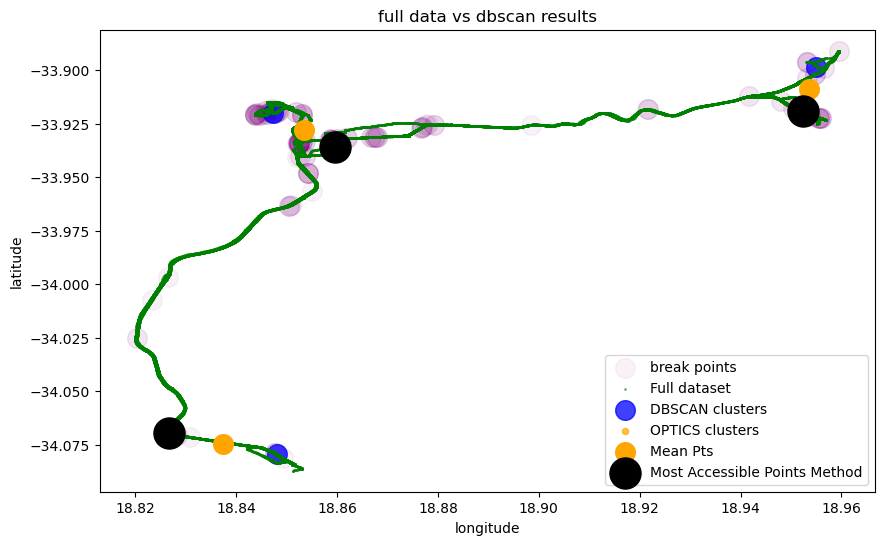

In [11]:
fig, ax = plt.subplots(figsize = [10,6])
bp_scatter = ax.scatter(dwell_points_df['lon'], dwell_points_df['lat'], c = 'purple', alpha = 0.05, s = 200)
op_rs_scatter = ax.scatter(rep_points_op['lon'], rep_points_op['lat'], color = 'orange', edgecolor = None, alpha = 0.7, s = 20)
rs_scatter = ax.scatter(rep_points['lon'], rep_points['lat'], color = 'blue', edgecolor = None, alpha = 0.75, s = 200)
df_scatter = ax.scatter(all_coords['lon'], all_coords['lat'], c = 'green', alpha = 0.5, s = 1)
means_scatter = ax.scatter(means_df['lon'], means_df['lat'], c = 'orange', alpha = 1, s = 200)
maps_scatter = ax.scatter(most_accessible_df['lon'], most_accessible_df['lat'], c = 'black', alpha = 1, s = 500)
ax.set_title('full data vs dbscan results')
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
ax.legend([bp_scatter, df_scatter, rs_scatter, op_rs_scatter, means_scatter, maps_scatter], 
['break points', 'Full dataset', 'DBSCAN clusters', 'OPTICS clusters', 'Mean Pts',
'Most Accessible Points Method'])
#ax.text(18.89,-34, 'Pay most attention to the black points', fontweight = 'bold')
plt.show()